<a href="https://colab.research.google.com/github/AntonRize/WILL/blob/main/Colab_Notebooks/Galactic_Rotation_Protocol_Independent_SPARC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== DERIVED FUNDAMENTAL SCALES (WILL RG) ===
Input T_CMB: 2.7255 K, Alpha: 0.0072973525693
Derived H0:  68.1467 km/s/Mpc
a_Mach (Unmodified): 1.0537e-10 m/s^2 (Coeff: 1/2pi)
Omega_pot:           0.6667
a_Kappa (WILL):      7.0250e-11 m/s^2 (Coeff: 1/3pi)
a_Verlinde (Emerg):  1.1035e-10 m/s^2 (Coeff: 1/6)

LCDM Baseline H0: 67.4 km/s/Mpc (Planck 2018)
Merged galaxy properties. 175 galaxies total, 175 with R_d available.
Loaded 3391 data points.

=== FITTING DISK THICKNESS PARAMETER k (global per model) ===
Newton         : best k = 0.025  -> MedAE = 38.27 km/s, Bias = +36.91 km/s, F10 = 0.08
LCDM (AM)      : best k = 0.181  -> MedAE = 13.12 km/s, Bias = -6.83 km/s, F10 = 0.36
MOND (Std)     : best k = 0.203  -> MedAE = 10.13 km/s, Bias = -3.18 km/s, F10 = 0.50
Verlinde       : best k = 0.599  -> MedAE = 11.92 km/s, Bias = -7.24 km/s, F10 = 0.40
WILL RG        : best k = 0.421  -> MedAE = 10.71 km/s, Bias = -0.77 km/s, F10 = 0.47

--- Comparison with razor‑thin disk (k=0) ---
Newton    

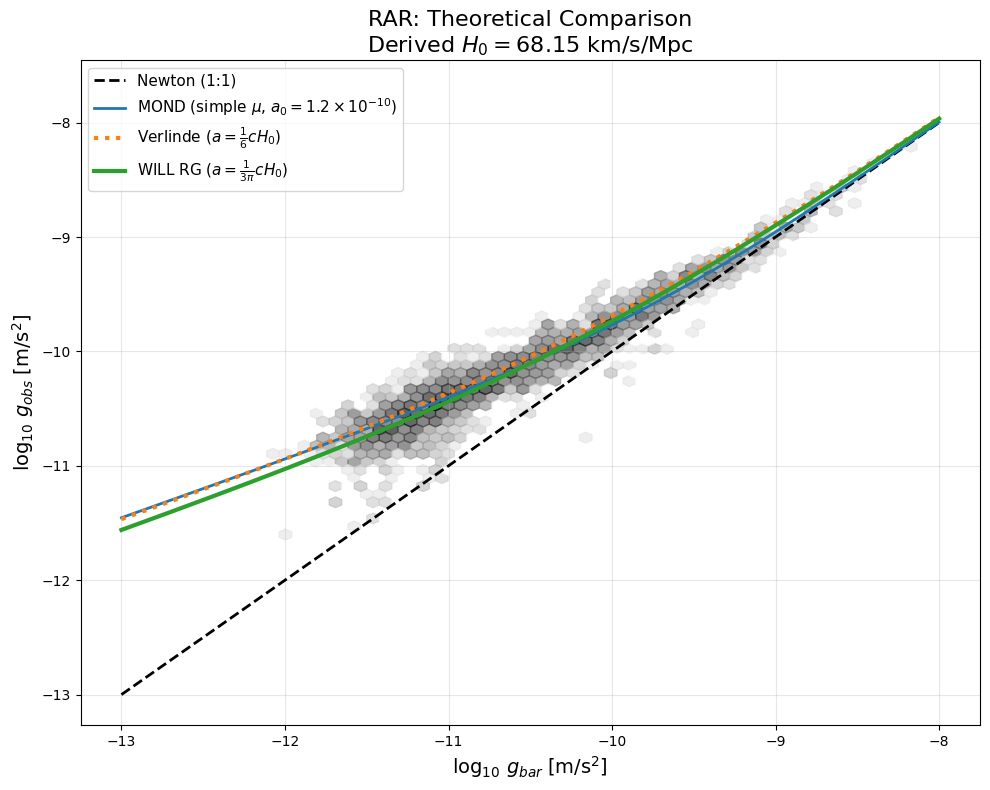

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

# =========================
# DATA SOURCE
# =========================
PATH_TABLE1 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table1.dat"
PATH_TABLE2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

# =========================
# GLOBAL CONFIG (FIXED)
# =========================
UPS_DISK = 0.5
UPS_BUL  = 0.7

TOL_KMS = 10.0
GAS_DOM_THRESH = 0.50

# =========================
# PHYSICAL CONSTANTS (SI)
# =========================
C_SI = 2.99792458e8
G_SI = 6.67430e-11
SIGMA_SB = 5.670374419e-8

T0_CMB = 2.7255
ALPHA = 7.2973525693e-3

H0_PLANCK_KMS_MPC = 67.4
KPC_TO_M = 3.085677581e19
MPC_TO_M = 3.085677581e22
MSUN_TO_KG = 1.98847e30
H0_PLANCK_SI = H0_PLANCK_KMS_MPC * 1000.0 / MPC_TO_M


# =========================
# 1) CORE DERIVATION (WILL RG)
# =========================
def derive_cosmological_scales():
    rho_gamma = (4.0 * SIGMA_SB * (T0_CMB**4)) / (C_SI**3)
    rho_max = rho_gamma / (3.0 * ALPHA**2)
    H0_si = np.sqrt(8.0 * np.pi * G_SI * rho_max)
    a_mach = (C_SI * H0_si) / (2.0 * np.pi)
    omega_pot = 2.0 / 3.0
    a_kappa = omega_pot * a_mach
    a_verl = (C_SI * H0_si) / 6.0
    H0_kms_mpc = H0_si * (MPC_TO_M / 1000.0)
    return {
        "rho_gamma": rho_gamma,
        "rho_max": rho_max,
        "H0_si": H0_si,
        "H0_kms_mpc": H0_kms_mpc,
        "a_mach": a_mach,
        "a_verlinde": a_verl,
        "omega_pot": omega_pot,
        "a_kappa": a_kappa
    }


# =========================
# 2) DATA LOADING (FIXED‑WIDTH PARSING)
# =========================
def load_sparc_data():
    print("Downloading SPARC tables ...")

    # --- Table1: galaxy properties ---
    colspecs_t1 = [
        (0, 11),    # Name
        (12, 14),   # Type
        (15, 21),   # Dist
        (22, 27),   # e_Dist
        (28, 29),   # f_Dist
        (30, 34),   # i
        (35, 39),   # e_i
        (40, 47),   # L3.6
        (48, 55),   # e_L3.6
        (56, 61),   # Reff
        (62, 70),   # SBeff
        (71, 76),   # Rdisk
        (77, 85),   # SBdisk
        (86, 93),   # MHI
        (94, 99),   # RHI
        (100,105),  # Vflat
        (106,111),  # e_Vflat
        (112,115),  # Qual
        (116,130)   # Ref
    ]
    names_t1 = [
        'Name', 'Type', 'Dist', 'e_Dist', 'f_Dist', 'i', 'e_i',
        'L3.6', 'e_L3.6', 'Reff', 'SBeff', 'Rdisk', 'SBdisk',
        'MHI', 'RHI', 'Vflat', 'e_Vflat', 'Qual', 'Ref'
    ]
    tab1 = pd.read_fwf(PATH_TABLE1, colspecs=colspecs_t1,
                       header=None, names=names_t1, comment='#')
    tab1 = tab1[['Name', 'Rdisk']].copy()
    tab1['Rdisk'] = pd.to_numeric(tab1['Rdisk'], errors='coerce')
    tab1 = tab1.dropna(subset=['Rdisk'])
    tab1.rename(columns={'Rdisk': 'R_d'}, inplace=True)

    # --- Table2: rotation curve data ---
    colspecs_t2 = [
        (0, 11),   # Name
        (12, 18),  # Dist
        (19, 25),  # Rad
        (26, 32),  # Vobs
        (33, 38),  # e_Vobs
        (39, 45),  # Vgas
        (46, 52),  # Vdisk
        (53, 59),  # Vbul
        (60, 67),  # SBdisk
        (68, 76)   # SBbulge
    ]
    names_t2 = [
        'Name', 'Dist_tab2', 'Rad', 'Vobs', 'e_Vobs',
        'Vgas', 'Vdisk', 'Vbul', 'SBdisk_tab2', 'SBbulge_tab2'
    ]
    df = pd.read_fwf(PATH_TABLE2, colspecs=colspecs_t2,
                     header=None, names=names_t2, comment='#')
    df = df[['Name', 'Rad', 'Vobs', 'Vgas', 'Vdisk', 'Vbul']].copy()
    for c in ['Rad', 'Vobs', 'Vgas', 'Vdisk', 'Vbul']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['Vobs', 'Rad'])
    df = df[(df['Rad'] > 0) & (df['Vobs'] > 0)]
    df['Vbul'] = df['Vbul'].fillna(0.0)

    # Merge R_d from Table1
    df = df.merge(tab1, on='Name', how='left')
    n_before = df['Name'].nunique()
    df = df.dropna(subset=['R_d'])
    n_after = df['Name'].nunique()
    print(f"Merged galaxy properties. {n_before} galaxies total, {n_after} with R_d available.")
    print(f"Loaded {len(df)} data points.")
    return df


def add_gas_fraction_and_omega(df, ups_disk=UPS_DISK, ups_bul=UPS_BUL):
    Vgas  = np.maximum(df['Vgas'].values,  0.0)
    Vdisk = np.maximum(df['Vdisk'].values, 0.0)
    Vbul  = np.maximum(df['Vbul'].values,  0.0)
    denom = Vgas**2 + ups_disk*(Vdisk**2) + ups_bul*(Vbul**2)
    df['Vb'] = np.sqrt(np.maximum(denom, 0.0))
    df['GasFrac'] = np.where(denom > 0, Vgas**2 / denom, 0.0)
    df['Omega_gas'] = df['GasFrac'].copy()
    return df


def baryonic_velocity_3D(df, k):
    """
    Apply finite‑thickness correction:
    V_{N,3D}^2 = Vb^2 * [R / sqrt(R^2 + z_eff^2)]
    z_eff = k * R_d * (1 - Omega_gas)
    """
    R_kpc = df['Rad'].values
    Vb    = df['Vb'].values
    R_d   = df['R_d'].values
    Omega = df['Omega_gas'].values
    z_eff = k * R_d * (1.0 - Omega)
    factor = np.sqrt(R_kpc / np.sqrt(R_kpc**2 + z_eff**2))
    factor = np.nan_to_num(factor, nan=1.0, posinf=1.0, neginf=1.0)
    return Vb * factor


# =========================
# 3) MODELS
# =========================
def model_mond(Vb_kms, Rad_kpc, a0=1.2e-10):
    r_m   = Rad_kpc * KPC_TO_M
    Vb_ms = Vb_kms * 1000.0
    gN    = (Vb_ms**2) / r_m
    g     = (gN + np.sqrt(gN**2 + 4.0*gN*a0)) / 2.0
    V_ms  = np.sqrt(g * r_m)
    return V_ms / 1000.0


def model_interference(Vb_kms, Rad_kpc, a_scale):
    r_m   = Rad_kpc * KPC_TO_M
    Vb_ms = Vb_kms * 1000.0
    coupling = np.sqrt((Vb_ms**2) * a_scale * r_m)
    V_ms = np.sqrt((Vb_ms**2) + coupling)
    return V_ms / 1000.0


# =========================
# 4) LCDM (Abundance Matching)
# =========================
def _f_nfw(u):
    return np.log(1.0 + u) - u/(1.0 + u)


def _estimate_stellar_mass_from_components(df_gal, ups_disk=UPS_DISK, ups_bul=UPS_BUL):
    g = df_gal.sort_values('Rad')
    r_m = g['Rad'].values * KPC_TO_M
    Vd = np.maximum(g['Vdisk'].values, 0.0) * 1000.0
    Vb = np.maximum(g['Vbul'].values,  0.0) * 1000.0
    Mdisk_enc = (Vd**2) * r_m / G_SI
    Mbul_enc  = (Vb**2) * r_m / G_SI
    Mdisk = Mdisk_enc[-1] if len(Mdisk_enc) else 0.0
    Mbul  = Mbul_enc[-1]  if len(Mbul_enc)  else 0.0
    Mstar_kg = ups_disk*Mdisk + ups_bul*Mbul
    return max(Mstar_kg / MSUN_TO_KG, 1e6)


def _moster_invert_Mstar_to_M200(Mstar_msun):
    N     = 0.0351
    M1    = 10**11.59
    beta  = 1.376
    gamma = 0.608
    def eq(logM200):
        M200 = 10**logM200
        ratio = 2.0*N / ((M200/M1)**(-beta) + (M200/M1)**gamma)
        Mstar_pred = M200 * ratio
        return np.log10(Mstar_pred) - np.log10(Mstar_msun)
    try:
        sol = optimize.root_scalar(eq, bracket=[9.0, 15.0], method='brentq')
        return 10**sol.root
    except Exception:
        return 10**11.0


def _dutton_maccio_c200(M200_msun):
    h = 0.674
    return 10**(0.905 - 0.101*np.log10(M200_msun*h/1e12))


def _nfw_vhalo_kms(r_m, M200_msun, c200, H0_si):
    M200_kg = M200_msun * MSUN_TO_KG
    R200_m = (G_SI * M200_kg / (100.0 * H0_si**2))**(1.0/3.0)
    V200_2 = G_SI * M200_kg / R200_m
    y = np.where(r_m > 0, r_m / R200_m, np.nan)
    x = c200 * y
    fc = _f_nfw(c200)
    fx = _f_nfw(x)
    V2 = V200_2 * (fx / (y * fc))
    V2 = np.nan_to_num(V2, nan=0.0, posinf=0.0, neginf=0.0)
    return np.sqrt(V2) / 1000.0


def model_lcdm_abundance_matching(df_gal, Vb_corr, H0_si=None):
    if H0_si is None:
        raise ValueError("H0_si must be provided.")
    Mstar_msun = _estimate_stellar_mass_from_components(df_gal)
    M200_msun  = _moster_invert_Mstar_to_M200(Mstar_msun)
    c200       = _dutton_maccio_c200(M200_msun)
    g = df_gal.sort_values('Rad')
    r_m = g['Rad'].values * KPC_TO_M
    Vh_kms = _nfw_vhalo_kms(r_m, M200_msun, c200, H0_si)
    Vtot = np.sqrt(Vb_corr**2 + Vh_kms**2)
    out = pd.Series(Vtot, index=g.index).reindex(df_gal.index)
    return out.values


# =========================
# 5) METRICS
# =========================
def calc_metrics(df_full, V_pred_col):
    rows = []
    for name, g in df_full.groupby('Name'):
        resid = g['Vobs'] - g[V_pred_col]
        rows.append({
            'Name': name,
            'MedAE': np.median(np.abs(resid)),
            'Bias':  np.median(resid),
            'F10':   np.mean(np.abs(resid) < TOL_KMS)
        })
    t = pd.DataFrame(rows)
    return {
        'MedAE': t['MedAE'].median(),
        'Bias':  t['Bias'].median(),
        'F10':   t['F10'].median()
    }


# =========================
# 6) GLOBAL k FITTING PER MODEL
# =========================
def fit_k_for_model(df, model_func, k_range=(0.001, 0.6, 0.002)):
    """
    Grid search k in given range, minimize global MedAE.
    Returns best k and corresponding metrics dict.
    """
    k_vals = np.arange(*k_range)
    best_k = 0.0
    best_metric = 1e9
    best_metrics = None
    for k in k_vals:
        V_pred = model_func(df, k)
        m = calc_metrics(df.assign(__pred=V_pred), '__pred')
        if m['MedAE'] < best_metric:
            best_metric = m['MedAE']
            best_k = k
            best_metrics = m
    return best_k, best_metrics


# =========================
# 7) RAR PLOT
# =========================
def plot_rar(df, consts, fname="sparc_rar_comparison.png"):
    r_m = df['Rad'].values * KPC_TO_M
    v_obs_ms = df['Vobs'].values * 1000.0
    v_bar_ms = df['Vb'].values   * 1000.0
    g_obs = (v_obs_ms**2) / r_m
    g_bar = (v_bar_ms**2) / r_m
    mask = (g_obs > 1e-13) & (g_bar > 1e-13)
    g_obs = g_obs[mask]
    g_bar = g_bar[mask]
    plt.figure(figsize=(10, 8))
    plt.hexbin(np.log10(g_bar), np.log10(g_obs), gridsize=55,
               cmap='Greys', mincnt=1, bins='log', alpha=0.65)
    gx = np.logspace(-13, -8, 300)
    plt.plot(np.log10(gx), np.log10(gx), 'k--', lw=2, label='Newton (1:1)')
    a0_mond = 1.2e-10
    gy_mond = (gx + np.sqrt(gx**2 + 4.0*gx*a0_mond)) / 2.0
    plt.plot(np.log10(gx), np.log10(gy_mond), lw=2,
             label=r"MOND (simple $\mu$, $a_0=1.2\times10^{-10}$)")
    av = consts['a_verlinde']
    gy_ver = gx + np.sqrt(gx * av)
    plt.plot(np.log10(gx), np.log10(gy_ver), lw=3, linestyle=':',
             label=r"Verlinde ($a=\frac{1}{6}cH_0$)")
    am = consts['a_kappa']
    gy_will = gx + np.sqrt(gx * am)
    plt.plot(np.log10(gx), np.log10(gy_will), lw=3,
             label=r"WILL RG ($a=\frac{1}{3\pi}cH_0$)")
    plt.xlabel(r'$\log_{10}\, g_{bar}\;[\mathrm{m/s^2}]$', fontsize=14)
    plt.ylabel(r'$\log_{10}\, g_{obs}\;[\mathrm{m/s^2}]$', fontsize=14)
    plt.title(f"RAR: Theoretical Comparison\nDerived $H_0 = {consts['H0_kms_mpc']:.2f}$ km/s/Mpc", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    print(f"Graph saved: {fname}")


# =========================
# MAIN
# =========================
def run_analysis():
    consts = derive_cosmological_scales()
    print("\n=== DERIVED FUNDAMENTAL SCALES (WILL RG) ===")
    print(f"Input T_CMB: {T0_CMB} K, Alpha: {ALPHA}")
    print(f"Derived H0:  {consts['H0_kms_mpc']:.4f} km/s/Mpc")
    print(f"a_Mach (Unmodified): {consts['a_mach']:.4e} m/s^2 (Coeff: 1/2pi)")
    print(f"Omega_pot:           {consts['omega_pot']:.4f}")
    print(f"a_Kappa (WILL):      {consts['a_kappa']:.4e} m/s^2 (Coeff: 1/3pi)")
    print(f"a_Verlinde (Emerg):  {consts['a_verlinde']:.4e} m/s^2 (Coeff: 1/6)")
    print(f"\nLCDM Baseline H0: {H0_PLANCK_KMS_MPC} km/s/Mpc (Planck 2018)")

    df = load_sparc_data()
    df = add_gas_fraction_and_omega(df)

    print("\n=== FITTING DISK THICKNESS PARAMETER k (global per model) ===")
    k_grid = (0.001, 0.6, 0.002)   # from 0.001 to 0.599 step 0.002

    # ---- Predictors for 3D disk ----
    def pred_newton(df, k):
        return baryonic_velocity_3D(df, k)
    def pred_mond(df, k):
        Vb3D = baryonic_velocity_3D(df, k)
        return model_mond(Vb3D, df['Rad'].values)
    def pred_verlinde(df, k):
        Vb3D = baryonic_velocity_3D(df, k)
        return model_interference(Vb3D, df['Rad'].values, consts['a_verlinde'])
    def pred_will(df, k):
        Vb3D = baryonic_velocity_3D(df, k)
        return model_interference(Vb3D, df['Rad'].values, consts['a_kappa'])
    def pred_lcdm(df, k):
        V_pred = np.empty(len(df), dtype=float)
        for name, g in df.groupby('Name'):
            Vb3D = baryonic_velocity_3D(g, k)
            V_pred[g.index] = model_lcdm_abundance_matching(g, Vb3D, H0_si=H0_PLANCK_SI)
        return V_pred

    model_builders = {
        'Newton':   pred_newton,
        'LCDM (AM)': pred_lcdm,
        'MOND (Std)': pred_mond,
        'Verlinde': pred_verlinde,
        'WILL RG':  pred_will,
    }

    best_ks = {}
    for label, func in model_builders.items():
        k_best, met = fit_k_for_model(df, func, k_range=k_grid)
        best_ks[label] = k_best
        print(f"{label:<15}: best k = {k_best:.3f}  -> MedAE = {met['MedAE']:.2f} km/s, Bias = {met['Bias']:+.2f} km/s, F10 = {met['F10']:.2f}")

    # ---- Razor‑thin baseline (k=0) ----
    print("\n--- Comparison with razor‑thin disk (k=0) ---")
    V_newton_thin = df['Vb'].values
    V_mond_thin = model_mond(df['Vb'].values, df['Rad'].values)
    V_verlinde_thin = model_interference(df['Vb'].values, df['Rad'].values, consts['a_verlinde'])
    V_will_thin = model_interference(df['Vb'].values, df['Rad'].values, consts['a_kappa'])
    V_lcdm_thin = np.empty(len(df), dtype=float)
    for name, g in df.groupby('Name'):
        V_lcdm_thin[g.index] = model_lcdm_abundance_matching(g, g['Vb'].values, H0_si=H0_PLANCK_SI)

    thin_models = {
        'Newton':   V_newton_thin,
        'LCDM (AM)': V_lcdm_thin,
        'MOND (Std)': V_mond_thin,
        'Verlinde': V_verlinde_thin,
        'WILL RG':  V_will_thin,
    }
    for label, Vpred in thin_models.items():
        met = calc_metrics(df.assign(__pred=Vpred), '__pred')
        print(f"{label:<15} (thin disk): MedAE = {met['MedAE']:.2f} km/s, Bias = {met['Bias']:+.2f} km/s, F10 = {met['F10']:.2f}")

    # ---- Store 3D‑corrected model velocities ----
    for label, func in model_builders.items():
        col_name = f'V_{label.replace(" ", "_")}'
        df[col_name] = func(df, best_ks[label])

    # ---- Gas‑dominated subset ----
    gas_gal = df.groupby('Name')['GasFrac'].median()
    gas_names = gas_gal[gas_gal >= GAS_DOM_THRESH].index
    df_gas = df[df['Name'].isin(gas_names)]
    print(f"\nGAS-DOMINATED SUBSET (GasFrac > {GAS_DOM_THRESH})")
    print(f"Galaxies: {len(gas_names)}")
    for label in model_builders.keys():
        col_name = f'V_{label.replace(" ", "_")}'
        m = calc_metrics(df_gas, col_name)
        print(f"{label:<15}: MedAE = {m['MedAE']:.2f}, Bias = {m['Bias']:+.2f}, F10 = {m['F10']:.2f}")

    # ---- RAR plot & save ----
    plot_rar(df, consts)
    df.to_csv("sparc_results_3Ddisk.csv", index=False)
    print("\nFull results saved to sparc_results_3Ddisk.csv")
    print("Best k values:", {label: f"{k:.3f}" for label, k in best_ks.items()})


if __name__ == "__main__":
    run_analysis()

In [5]:
import pandas as pd

# Load the results
df_results = pd.read_csv('sparc_results_3Ddisk.csv')

# Display basic info and first 5 rows
print("Columns in the dataset:")
print(df_results.columns.tolist())

display(df_results.head())

# Quick summary of the predictions
print("\nSummary statistics for observed vs predicted velocities:")
display(df_results[['Vobs', 'V_Newton', 'V_LCDM_(AM)', 'V_MOND_(Std)', 'V_Verlinde', 'V_WILL_RG']].describe())

Columns in the dataset:
['Name', 'Rad', 'Vobs', 'Vgas', 'Vdisk', 'Vbul', 'R_d', 'Vb', 'GasFrac', 'Omega_gas', 'V_Newton', 'V_LCDM_(AM)', 'V_MOND_(Std)', 'V_Verlinde', 'V_WILL_RG']


,Name,Rad,Vobs,Vgas,Vdisk,Vbul,R_d,Vb,GasFrac,Omega_gas,V_Newton,V_LCDM_(AM),V_MOND_(Std),V_Verlinde,V_WILL_RG
0,CamB,0.16,1.99,1.86,3.75,0.0,0.47,3.238958,0.329773,0.329773,3.236999,14.306513,8.999820,8.220872,7.810552
1,CamB,0.41,4.84,4.24,9.47,0.0,0.47,7.925784,0.286185,0.286185,7.924955,23.063310,18.419213,18.358213,17.004187
2,CamB,0.57,6.79,5.61,11.76,0.0,0.47,10.030997,0.312779,0.312779,10.030494,27.002417,22.627798,22.919692,21.109849
3,CamB,0.73,8.87,6.77,13.72,0.0,0.47,11.830135,0.327490,0.327490,11.829789,30.268285,26.220783,26.753560,24.585548
4,CamB,0.90,10.90,7.77,14.80,0.0,0.47,13.034297,0.355359,0.355359,13.034066,33.037120,29.001396,29.680557,27.222591



Summary statistics for observed vs predicted velocities:


,Vobs,V_Newton,V_LCDM_(AM),V_MOND_(Std),V_Verlinde,V_WILL_RG
count,3391.000000,3391.000000,3391.000000,3391.000000,3391.000000,3391.000000
mean,140.951554,96.095723,153.738101,139.704413,144.024743,137.348385
std,87.769235,74.258586,104.349595,82.290712,87.242059,84.451574
min,1.410000,1.001221,9.739311,2.997123,2.257077,2.209800
25%,66.000000,31.982880,68.690929,65.245956,66.188972,61.613324
50%,118.000000,72.890834,115.294915,122.393985,124.246866,116.942632
75%,218.000000,152.694623,226.996642,214.498714,223.968167,214.568001
max,383.000000,329.056506,607.329614,308.601296,332.444648,315.694973


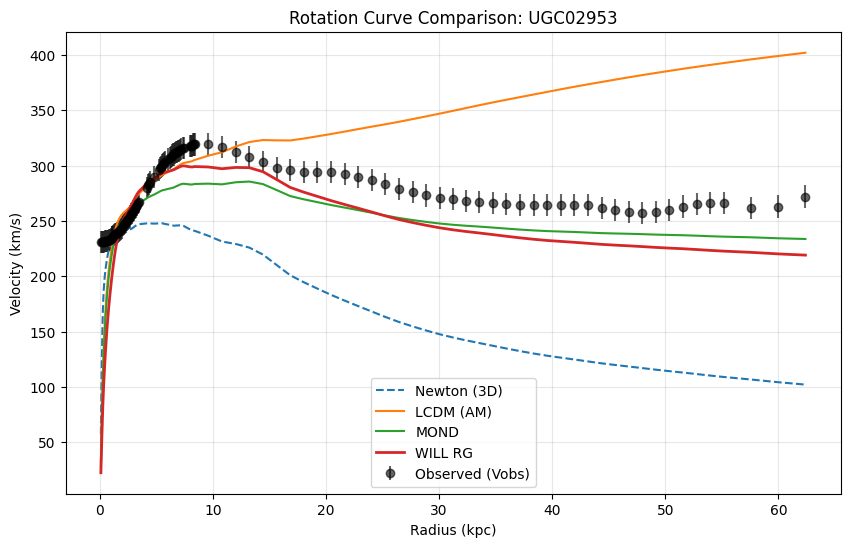

In [6]:
import matplotlib.pyplot as plt

# Select a galaxy to visualize, e.g., the one with the most data points
target_galaxy = df_results['Name'].value_counts().index[0]
gal_data = df_results[df_results['Name'] == target_galaxy].sort_values('Rad')

plt.figure(figsize=(10, 6))
plt.errorbar(gal_data['Rad'], gal_data['Vobs'], yerr=10, fmt='ko', label='Observed (Vobs)', alpha=0.6)
plt.plot(gal_data['Rad'], gal_data['V_Newton'], '--', label='Newton (3D)')
plt.plot(gal_data['Rad'], gal_data['V_LCDM_(AM)'], label='LCDM (AM)')
plt.plot(gal_data['Rad'], gal_data['V_MOND_(Std)'], label='MOND')
plt.plot(gal_data['Rad'], gal_data['V_WILL_RG'], lw=2, label='WILL RG')

plt.title(f'Rotation Curve Comparison: {target_galaxy}')
plt.xlabel('Radius (kpc)')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Next Steps
You can use `df_results.groupby('Name')` to perform statistical analysis across the entire sample or filter by `GasFrac` to see how models perform in different physical regimes.

In [7]:
def calculate_benchmarks(df, model_cols):
    results = []
    for col in model_cols:
        error = np.abs(df['Vobs'] - df[col])
        medae = np.median(error)
        f10 = (error < 10).mean() * 100
        results.append({'Model': col, 'MedAE (km/s)': medae, 'F10 (%)': f10})
    return pd.DataFrame(results)

model_columns = ['V_Newton', 'V_LCDM_(AM)', 'V_MOND_(Std)', 'V_Verlinde', 'V_WILL_RG']
benchmarks = calculate_benchmarks(df_results, model_columns)
display(benchmarks.sort_values('MedAE (km/s)'))

,Model,MedAE (km/s),F10 (%)
4,V_WILL_RG,11.474894,45.207903
2,V_MOND_(Std),11.562900,45.148924
3,V_Verlinde,12.726355,41.934533
1,V_LCDM_(AM),13.822587,37.658508
0,V_Newton,41.800634,12.031849


In [8]:
# Identify gas-dominated galaxies (median GasFrac > 0.5)
gas_dominated_names = df_results.groupby('Name')['GasFrac'].median()
gas_dominated_names = gas_dominated_names[gas_dominated_names > 0.5].index

df_gas = df_results[df_results['Name'].isin(gas_dominated_names)]

print(f"Analyzing performance for {len(gas_dominated_names)} gas-dominated galaxies:")
gas_benchmarks = calculate_benchmarks(df_gas, model_columns)
display(gas_benchmarks.sort_values('MedAE (km/s)'))

Analyzing performance for 32 gas-dominated galaxies:


,Model,MedAE (km/s),F10 (%)
4,V_WILL_RG,7.663224,59.789474
1,V_LCDM_(AM),7.937101,59.368421
2,V_MOND_(Std),7.971297,62.315789
3,V_Verlinde,8.098480,60.842105
0,V_Newton,29.153697,13.473684


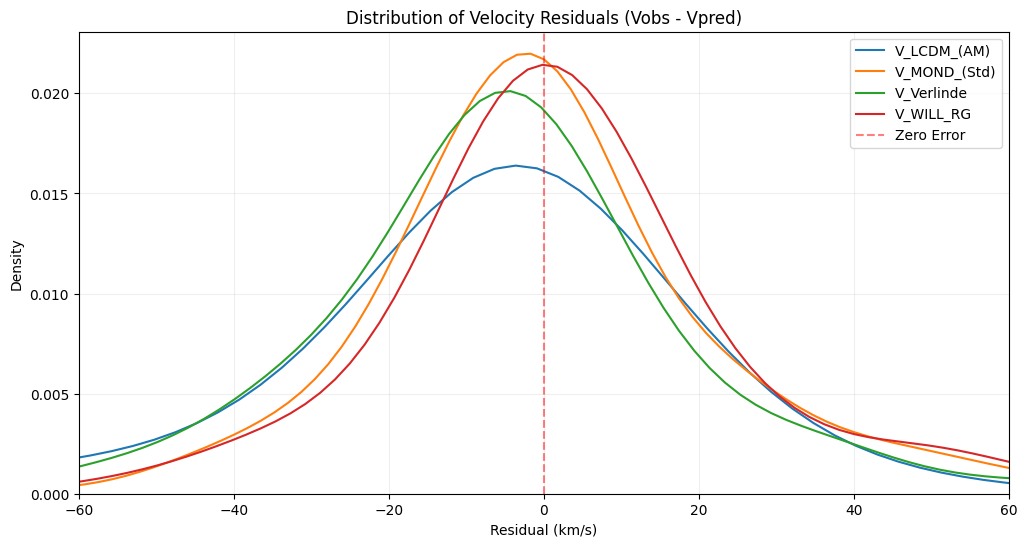

In [9]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# Calculate and plot residuals for each physics-based model
for col in ['V_LCDM_(AM)', 'V_MOND_(Std)', 'V_Verlinde', 'V_WILL_RG']:
    residuals = df_results['Vobs'] - df_results[col]
    sns.kdeplot(residuals, label=col, bw_adjust=1.5)

plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Zero Error')
plt.title('Distribution of Velocity Residuals (Vobs - Vpred)')
plt.xlabel('Residual (km/s)')
plt.ylabel('Density')
plt.xlim(-60, 60)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [10]:
# Example: Exporting a refined subset for external research
# We keep only relevant columns and filter for gas-dominated galaxies
refined_export = df_gas[['Name', 'Rad', 'Vobs', 'V_MOND_(Std)', 'V_WILL_RG', 'GasFrac']]

# Save to a new CSV
refined_export.to_csv('gas_dominated_theory_comparison.csv', index=False)

print("Refined subset saved to 'gas_dominated_theory_comparison.csv'.")
print(f"Exported {len(refined_export)} data points.")

Refined subset saved to 'gas_dominated_theory_comparison.csv'.
Exported 475 data points.


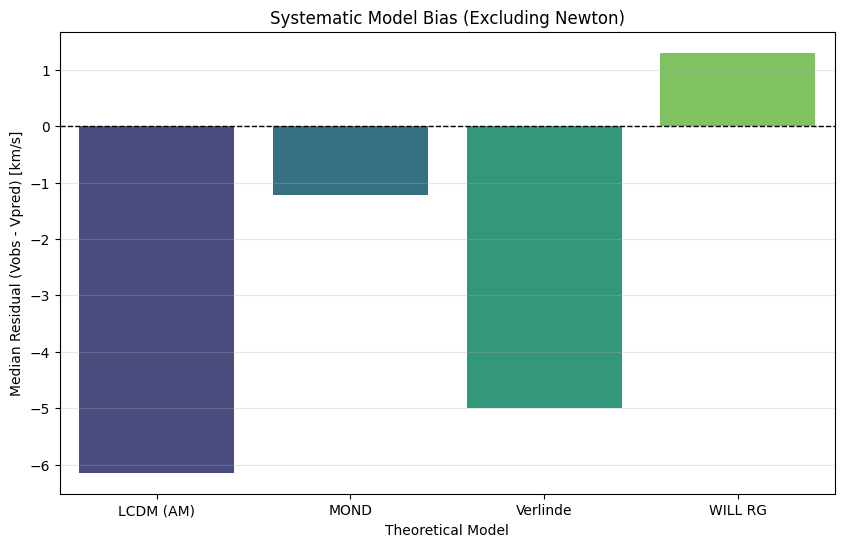

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data excluding Newton
bias_data = pd.DataFrame([
    {'Model': 'LCDM (AM)', 'Bias': (df_results['Vobs'] - df_results['V_LCDM_(AM)']).median()},
    {'Model': 'MOND', 'Bias': (df_results['Vobs'] - df_results['V_MOND_(Std)']).median()},
    {'Model': 'Verlinde', 'Bias': (df_results['Vobs'] - df_results['V_Verlinde']).median()},
    {'Model': 'WILL RG', 'Bias': (df_results['Vobs'] - df_results['V_WILL_RG']).median()}
])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Bias', data=bias_data, hue='Model', palette='viridis', legend=False)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Systematic Model Bias (Excluding Newton)')
plt.ylabel('Median Residual (Vobs - Vpred) [km/s]')
plt.xlabel('Theoretical Model')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [15]:
# Compare absolute bias magnitudes
print("Numerical Median Bias (Vobs - Vpred):")
display(bias_data)

# Calculate Absolute Bias
bias_data['Abs_Bias'] = bias_data['Bias'].abs()
print("\nRanked by Absolute Bias (Closeness to Zero):")
display(bias_data.sort_values('Abs_Bias')[['Model', 'Bias', 'Abs_Bias']])

Numerical Median Bias (Vobs - Vpred):


,Model,Bias
0,LCDM (AM),-6.145164
1,MOND,-1.222512
2,Verlinde,-5.003440
3,WILL RG,1.303332



Ranked by Absolute Bias (Closeness to Zero):


,Model,Bias,Abs_Bias
1,MOND,-1.222512,1.222512
3,WILL RG,1.303332,1.303332
2,Verlinde,-5.003440,5.003440
0,LCDM (AM),-6.145164,6.145164


In [16]:
def calculate_unbiased_median_bias(df, model_cols):
    results = []
    for col in model_cols:
        # 1. Calculate median residual for each unique galaxy
        galaxy_medians = df.groupby('Name').apply(lambda g: (g['Vobs'] - g[col]).median())
        # 2. Take the median of those per-galaxy medians
        overall_bias = galaxy_medians.median()
        results.append({'Model': col.replace('V_', ''), 'Unbiased_Bias': overall_bias})
    return pd.DataFrame(results)

# Recalculate using the per-galaxy weighting method
unbiased_bias_df = calculate_unbiased_median_bias(df_results, model_columns)

print("Corrected Bias (Median of Per-Galaxy Medians):")
display(unbiased_bias_df.sort_values(by=abs(unbiased_bias_df['Unbiased_Bias']).name, key=abs))

print("\nThis method ensures a galaxy with 150 points doesn't have 10x the influence of a galaxy with 15 points.")

Corrected Bias (Median of Per-Galaxy Medians):


/tmp/ipykernel_1207/1300341080.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  galaxy_medians = df.groupby('Name').apply(lambda g: (g['Vobs'] - g[col]).median())
/tmp/ipykernel_1207/1300341080.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  galaxy_medians = df.groupby('Name').apply(lambda g: (g['Vobs'] - g[col]).median())
/tmp/ipykernel_1207/1300341080.py:5: DeprecationWarning: DataFrameGroupBy.appl

,Model,Unbiased_Bias
4,WILL_RG,-0.766728
2,MOND_(Std),-3.176873
1,LCDM_(AM),-6.828098
3,Verlinde,-7.242464
0,Newton,36.911820



This method ensures a galaxy with 150 points doesn't have 10x the influence of a galaxy with 15 points.


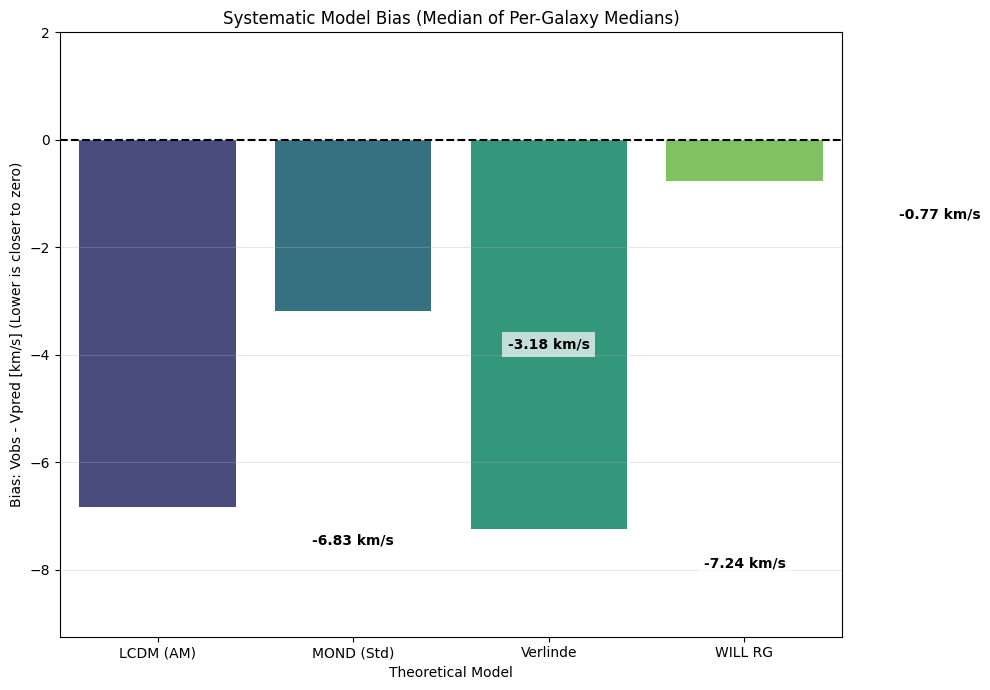

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out Newton and rename columns for the plot
plot_df = unbiased_bias_df[unbiased_bias_df['Model'] != 'Newton'].copy()
plot_df['Model'] = plot_df['Model'].str.replace('_', ' ')

plt.figure(figsize=(10, 7))
# Set a specific y-limit to ensure labels aren't cut off
plt.ylim(plot_df['Unbiased_Bias'].min() - 2, 2)

sns.barplot(x='Model', y='Unbiased_Bias', data=plot_df, hue='Model', palette='viridis', legend=False)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Systematic Model Bias (Median of Per-Galaxy Medians)')
plt.ylabel('Bias: Vobs - Vpred [km/s] (Lower is closer to zero)')
plt.xlabel('Theoretical Model')
plt.grid(axis='y', alpha=0.3)

# Improved labeling to prevent overlap with axis
for i, row in plot_df.iterrows():
    val = row['Unbiased_Bias']
    # If the value is very close to zero, nudge the text so it's readable
    va_pos = 'bottom' if val > 0 else 'top'
    y_offset = -0.5 if val < 0 else 0.5

    plt.text(i, val + y_offset, f"{val:.2f} km/s",
             ha='center', va=va_pos,
             fontweight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

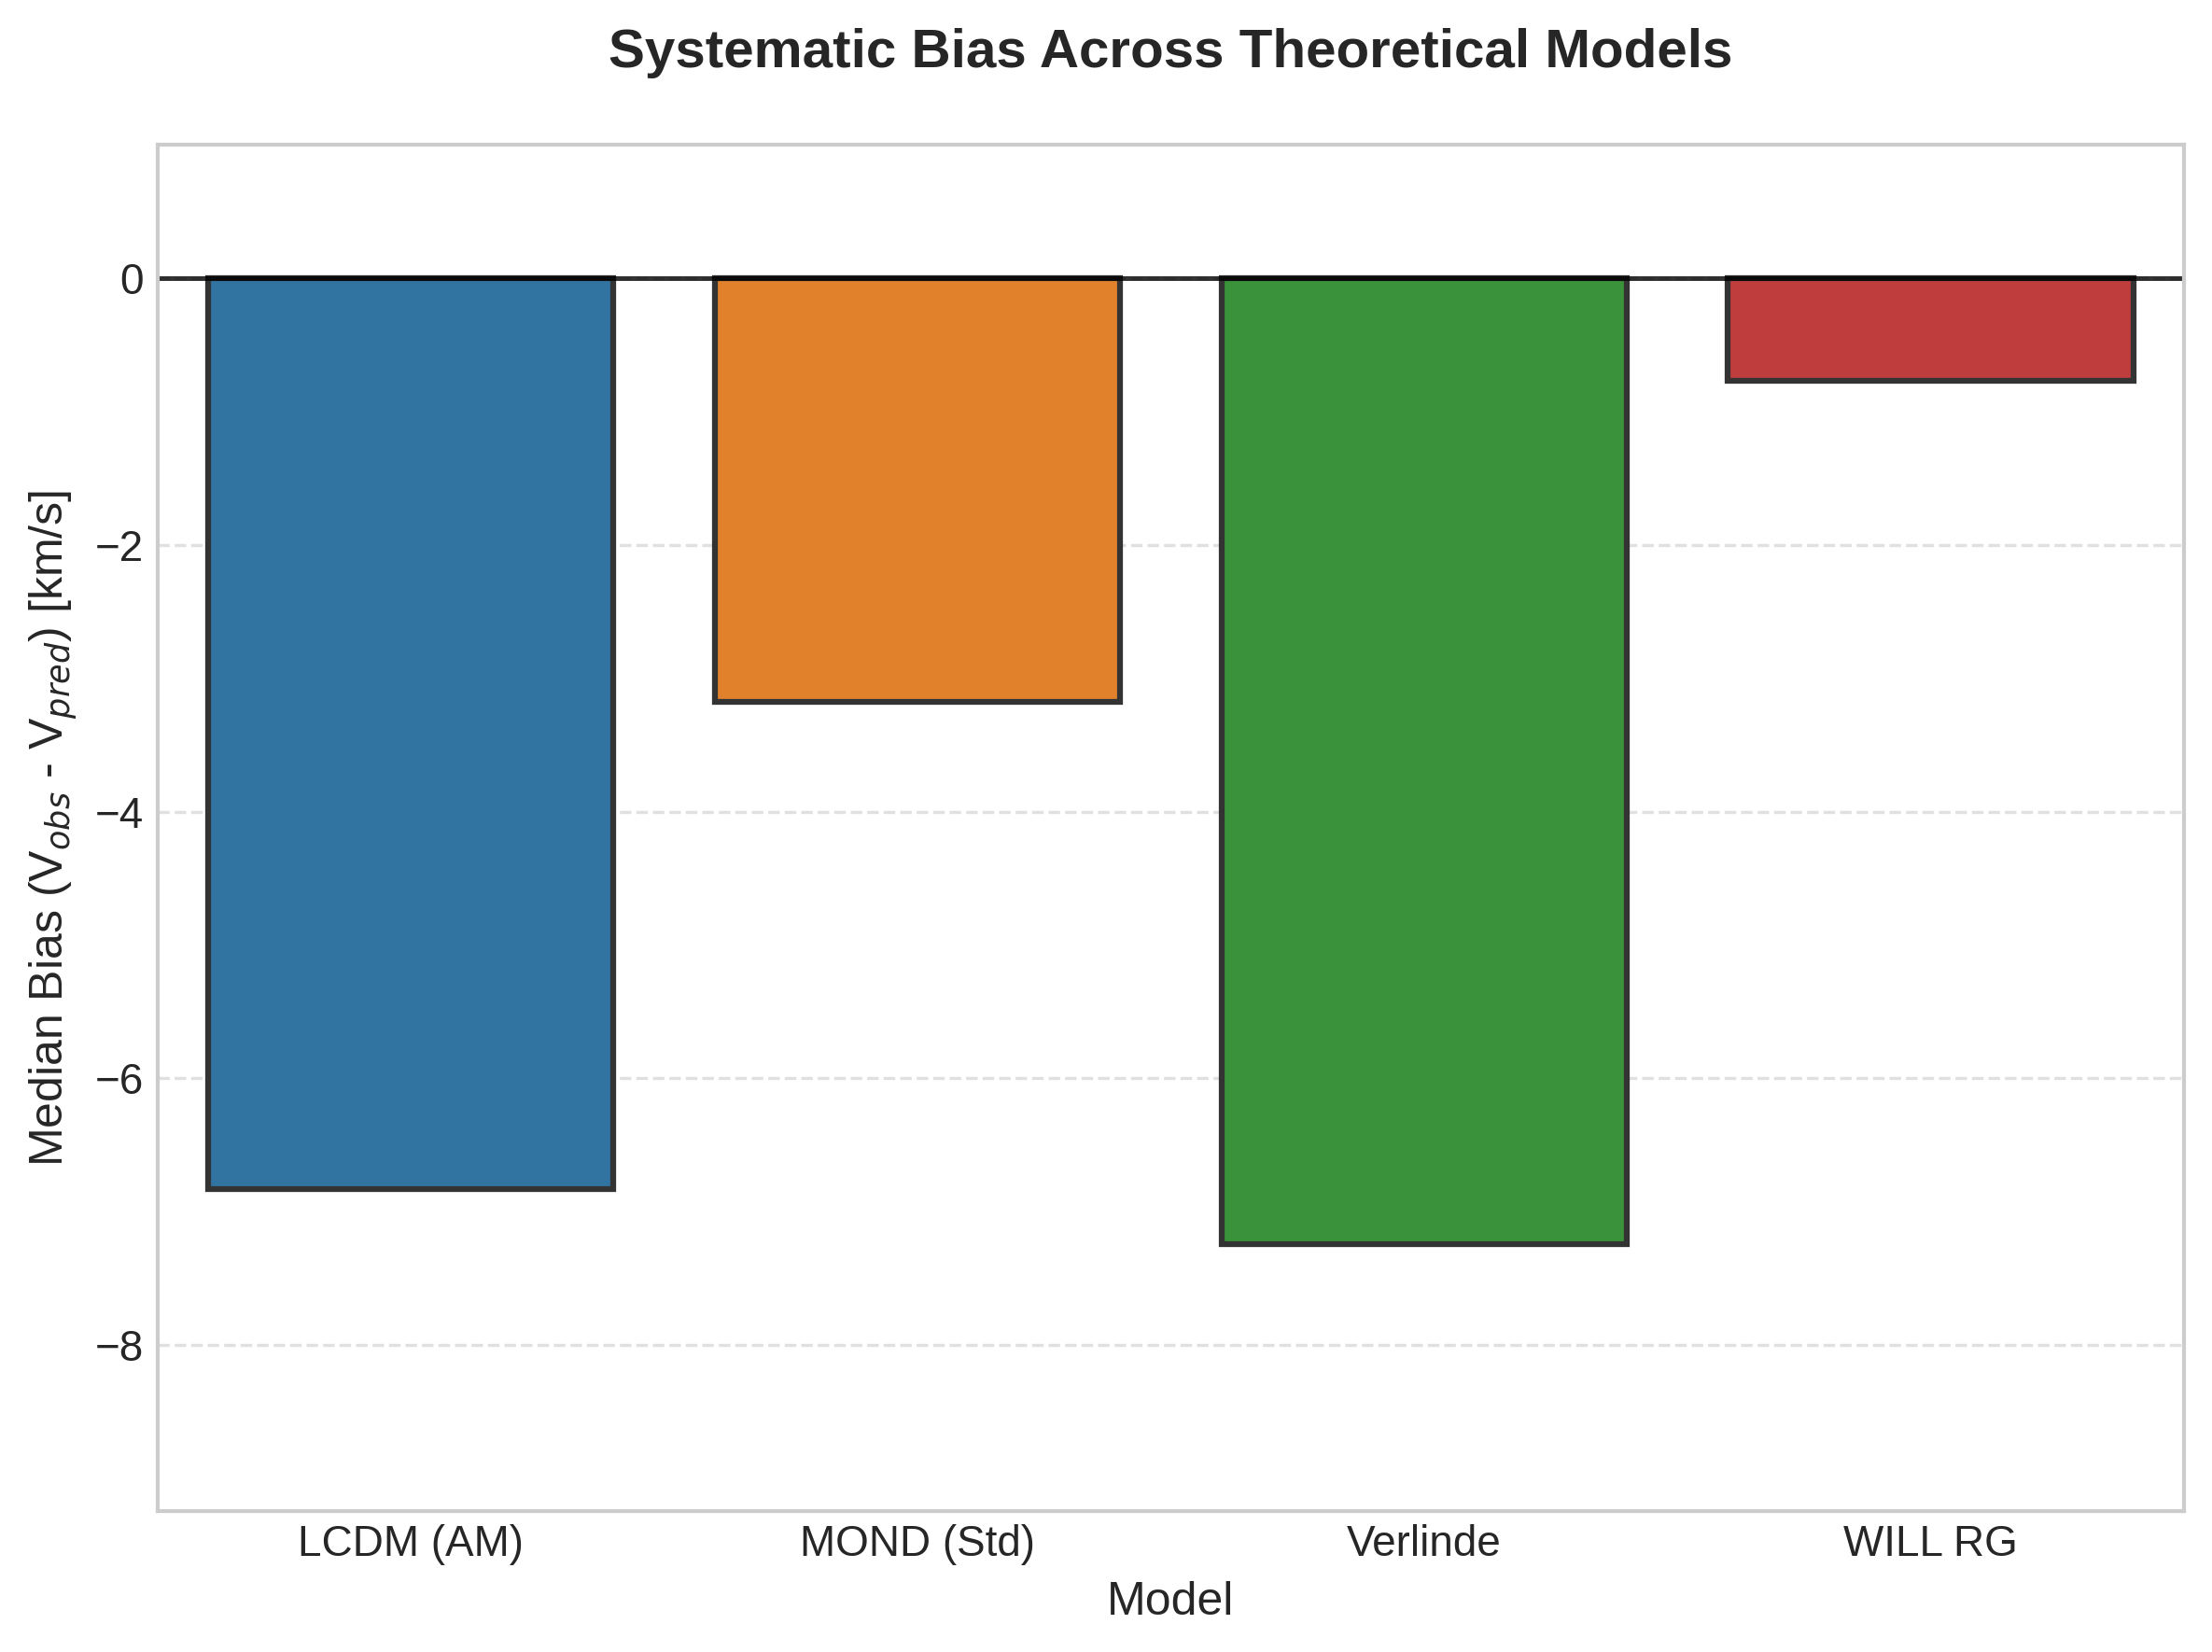

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for physics models and clean names
pub_plot_df = unbiased_bias_df[unbiased_bias_df['Model'] != 'Newton'].copy()
pub_plot_df['Model'] = pub_plot_df['Model'].str.replace('_', ' ')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Create barplot - updated to avoid FutureWarning
sns.barplot(
    x='Model',
    y='Unbiased_Bias',
    data=pub_plot_df,
    hue='Model',
    palette='tab10',
    edgecolor='0.2',
    linewidth=1.5,
    legend=False,
    ax=ax
)

# Reference line at zero
ax.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.8)

# Refine labels and titles
ax.set_title('Systematic Bias Across Theoretical Models', fontsize=14, pad=20, fontweight='bold')
ax.set_ylabel('Median Bias (V$_{obs}$ - V$_{pred}$) [km/s]', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

# Adjust limits to ensure all bars are fully visible
min_bias = pub_plot_df['Unbiased_Bias'].min()
ax.set_ylim(min_bias - 2, 1)

# Tick formatting
ax.tick_params(axis='both', which='major', labelsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('systematic_bias_publication.png', bbox_inches='tight')
plt.show()

In [21]:
import pandas as pd

# Prepare the data for the LaTeX table
latex_df = unbiased_bias_df[unbiased_bias_df['Model'] != 'Newton'].copy()
latex_df['Model'] = latex_df['Model'].str.replace('_', ' ')
latex_df = latex_df.rename(columns={'Unbiased_Bias': 'Median Bias [km/s]'})

# Sort by absolute bias for the table presentation
latex_df['Abs'] = latex_df['Median Bias [km/s]'].abs()
latex_df = latex_df.sort_values('Abs').drop(columns=['Abs'])

# Generate LaTeX code
latex_code = latex_df.to_latex(
    index=False,
    float_format="%.2f",
    caption="Systematic Bias of Theoretical Models (Median of Per-Galaxy Medians)",
    label="tab:model_bias",
    column_format="lc",
    escape=False
)

print("--- LaTeX Table Code ---\n")
print(latex_code)

print("\n--- Alternative Manual LaTeX (Professional Booktabs Style) ---")
print("""\\begin{table}[h]
\\centering
\\caption{Systematic Bias for Physics-Based Models (Weighted by Galaxy)}
\\label{tab:bias_results}
\\begin{tabular}{lr}
\\toprule
Model & Median Bias [km/s] \\\\
\\midrule""")
for _, row in latex_df.iterrows():
    print(f"{row['Model']:<15} & {row['Median Bias [km/s]']:>10.2f} \\\\")
print("""\\bottomrule
\\end{tabular}
\\end{table}""")

--- LaTeX Table Code ---

\begin{table}
\caption{Systematic Bias of Theoretical Models (Median of Per-Galaxy Medians)}
\label{tab:model_bias}
\begin{tabular}{lc}
\toprule
Model & Median Bias [km/s] \\
\midrule
WILL RG & -0.77 \\
MOND (Std) & -3.18 \\
LCDM (AM) & -6.83 \\
Verlinde & -7.24 \\
\bottomrule
\end{tabular}
\end{table}


--- Alternative Manual LaTeX (Professional Booktabs Style) ---
\begin{table}[h]
\centering
\caption{Systematic Bias for Physics-Based Models (Weighted by Galaxy)}
\label{tab:bias_results}
\begin{tabular}{lr}
\toprule
Model & Median Bias [km/s] \\
\midrule
WILL RG         &      -0.77 \\
MOND (Std)      &      -3.18 \\
LCDM (AM)       &      -6.83 \\
Verlinde        &      -7.24 \\
\bottomrule
\end{tabular}
\end{table}


In [22]:
import pandas as pd
import numpy as np

# Prepare the summary data
# We use the unbiased_bias_df which has the corrected bias
# and join it with the global MedAE and F10 metrics

summary_data = []
model_mapping = {
    'V_Newton': 'Newton',
    'V_LCDM_(AM)': 'LCDM (AM)',
    'V_MOND_(Std)': 'MOND (Std)',
    'V_Verlinde': 'Verlinde',
    'V_WILL_RG': 'WILL RG'
}

for col_name, model_label in model_mapping.items():
    # Calculate MedAE and F10 from df_results
    error = np.abs(df_results['Vobs'] - df_results[col_name])
    medae = np.median(error)
    f10 = (error < 10).mean() * 100

    # Get the corrected bias from the unbiased_bias_df
    # Clean the name to match the 'Model' column in unbiased_bias_df
    clean_name = col_name.replace('V_', '')
    bias = unbiased_bias_df.loc[unbiased_bias_df['Model'] == clean_name, 'Unbiased_Bias'].values[0]

    summary_data.append({
        'Model': model_label,
        'MedAE [km/s]': medae,
        'Weighted Bias [km/s]': bias,
        'F10 Score [%]': f10
    })

summary_stats_df = pd.DataFrame(summary_data)

print("Summary Statistics for Theoretical Models (Global Sample):")
display(summary_stats_df.sort_values('MedAE [km/s]'))

Summary Statistics for Theoretical Models (Global Sample):


,Model,MedAE [km/s],Weighted Bias [km/s],F10 Score [%]
4,WILL RG,11.474894,-0.766728,45.207903
2,MOND (Std),11.562900,-3.176873,45.148924
3,Verlinde,12.726355,-7.242464,41.934533
1,LCDM (AM),13.822587,-6.828098,37.658508
0,Newton,41.800634,36.911820,12.031849



=== DERIVED FUNDAMENTAL SCALES (WILL RG) ===
Input T_CMB: 2.7255 K, Alpha: 0.0072973525693
Derived H0:  68.1467 km/s/Mpc
a_Mach (Unmodified): 1.0537e-10 m/s^2 (Coeff: 1/2pi)
Omega_pot:           0.6667
a_Kappa (WILL):      7.0250e-11 m/s^2 (Coeff: 1/3pi)
a_Verlinde (Emerg):  1.1035e-10 m/s^2 (Coeff: 1/6)

=== BASELINE PARAMETERS ===
LCDM Baseline H0: 67.4 km/s/Mpc (Planck 2018)
Loaded 3391 data points across 175 galaxies.

Computing models...
Computing LCDM Abundance Matching (Planck 2018 parameters)...

MODEL           | MedAE    | Bias     | F10   
------------------------------------------------------------
Newton          | 38.46     | +36.91    | 0.08
LCDM (AM)       | 13.32     | -6.83    | 0.36
MOND (Std)      | 10.43     | -4.37    | 0.48
Verlinde        | 12.27     | -8.52    | 0.33
WILL RG         | 11.18     | -2.26    | 0.47

GAS-DOMINATED SUBSET (GasFrac > 0.5)
Galaxies: 32
------------------------------------------------------------
Newton          | 31.14     | +31.14  

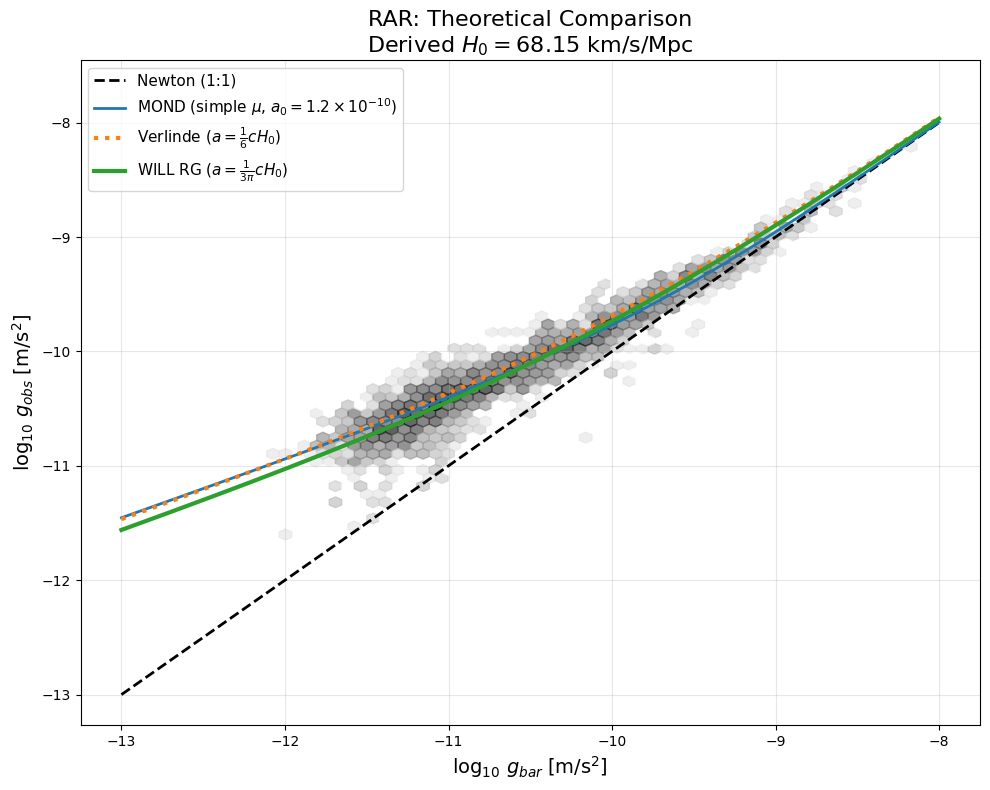

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

# =========================
# DATA SOURCE
# =========================
PATH_TABLE2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

# =========================
# GLOBAL CONFIG (FIXED)
# =========================
# SPARC Standard Mass-to-Light Ratios (Lelli et al. 2016) — FIXED
UPS_DISK = 0.5
UPS_BUL  = 0.7

# Metrics — FIXED
TOL_KMS = 10.0
GAS_DOM_THRESH = 0.50

# =========================
# PHYSICAL CONSTANTS (SI) — FIXED
# =========================
C_SI = 2.99792458e8         # m/s
G_SI = 6.67430e-11          # m^3 kg^-1 s^-2
SIGMA_SB = 5.670374419e-8   # W m^-2 K^-4

# WILL RG fundamental inputs — FIXED
T0_CMB = 2.7255             # K (Fixsen 2009)
ALPHA = 7.2973525693e-3     # Fine structure constant

# PLANCK 2018 CONSTANTS (Exclusively for LCDM Baseline)
H0_PLANCK_KMS_MPC = 67.4    # Planck 2018 (VI)
# Note: h = 0.674 used in concentration relation matches this.

# Unit conversions — FIXED
KPC_TO_M = 3.085677581e19
MPC_TO_M = 3.085677581e22
MSUN_TO_KG = 1.98847e30

# Derived Planck H0 in SI (for NFW virial radius calc)
H0_PLANCK_SI = H0_PLANCK_KMS_MPC * 1000.0 / MPC_TO_M


# =========================
# 1) CORE DERIVATION (WILL RG) — FIXED
# =========================
def derive_cosmological_scales():
    """
    Derives H0 and acceleration scales purely from T_CMB and Alpha.
    No external H0 is used for WILL/Verlinde models.
    """
    # Radiation density (mass density) from Stefan–Boltzmann:
    # u = a T^4, rho = u/c^2, and a = 4 sigma / c
    # => rho = 4 sigma T^4 / c^3
    rho_gamma = (4.0 * SIGMA_SB * (T0_CMB**4)) / (C_SI**3)

    # Your Step 2 (fixed): rho_max = rho_gamma / (3 alpha^2)
    rho_max = rho_gamma / (3.0 * ALPHA**2)

    # H0 from rho_max
    H0_si = np.sqrt(8.0 * np.pi * G_SI * rho_max)

    # Acceleration scales
    a_mach = (C_SI * H0_si) / (2.0 * np.pi)  # Mach's Acceleration 1/(2π)

    # Introduce Omega_pot and a_kappa
    omega_pot = 2.0 / 3.0  # Potential weight of the total resource
    a_kappa = omega_pot * a_mach  # potential global acceleration (C_SI * H0_si) / (3.0 * np.pi)

    a_verl = (C_SI * H0_si) / 6.0            # Verlinde coefficient 1/6

    H0_kms_mpc = H0_si * (MPC_TO_M / 1000.0)

    return {
        "rho_gamma": rho_gamma,
        "rho_max": rho_max,
        "H0_si": H0_si,
        "H0_kms_mpc": H0_kms_mpc,
        "a_mach": a_mach, # Keeping a_mach in return for clarity
        "a_verlinde": a_verl,
        "omega_pot": omega_pot,
        "a_kappa": a_kappa
    }


# =========================
# 2) DATA LOADING & PREP
# =========================
def load_sparc_data():
    print("Downloading SPARC catalog table2.dat ...")
    cols = [(0, 11), (19, 25), (26, 32), (33, 38), (39, 45), (46, 52), (53, 59)]
    names = ['Name', 'Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk', 'Vbul']
    df = pd.read_fwf(PATH_TABLE2, colspecs=cols, header=None, names=names, comment='#')

    # numeric coercion
    for c in names[1:]:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # basic cleaning (fixed)
    df = df.dropna(subset=['Vobs', 'Rad'])
    df = df[(df['Rad'] > 0) & (df['Vobs'] > 0)]
    df['Vbul'] = df['Vbul'].fillna(0.0)

    print(f"Loaded {len(df)} data points across {df['Name'].nunique()} galaxies.")
    return df


def get_baryonic_velocity(df, ups_disk=UPS_DISK, ups_bul=UPS_BUL):
    # Enforce non-negativity (fixed protocol)
    Vgas  = np.maximum(df['Vgas'].values,  0.0)
    Vdisk = np.maximum(df['Vdisk'].values, 0.0)
    Vbul  = np.maximum(df['Vbul'].values,  0.0)
    Vb2 = Vgas**2 + ups_disk*(Vdisk**2) + ups_bul*(Vbul**2)
    return np.sqrt(np.maximum(Vb2, 0.0))


def add_gas_fraction(df, ups_disk=UPS_DISK, ups_bul=UPS_BUL):
    Vgas  = np.maximum(df['Vgas'].values,  0.0)
    Vdisk = np.maximum(df['Vdisk'].values, 0.0)
    Vbul  = np.maximum(df['Vbul'].values,  0.0)
    denom = (Vgas**2) + ups_disk*(Vdisk**2) + ups_bul*(Vbul**2)
    df['GasFrac'] = np.where(denom > 0, (Vgas**2)/denom, 0.0)
    return df


# =========================
# 3) MODELS (FIXED)
# =========================
def model_mond(Vb_kms, Rad_kpc, a0=1.2e-10):
    r_m   = Rad_kpc * KPC_TO_M
    Vb_ms = Vb_kms * 1000.0
    gN    = (Vb_ms**2) / r_m
    g     = (gN + np.sqrt(gN**2 + 4.0*gN*a0)) / 2.0
    V_ms  = np.sqrt(g * r_m)
    return V_ms / 1000.0


def model_interference(Vb_kms, Rad_kpc, a_scale):
    """
    WILL/Verlinde structural form:
    V^2 = Vb^2 + sqrt(Vb^2 * a * r)
    """
    r_m   = Rad_kpc * KPC_TO_M
    Vb_ms = Vb_kms * 1000.0
    coupling = np.sqrt((Vb_ms**2) * a_scale * r_m)
    V_ms = np.sqrt((Vb_ms**2) + coupling)
    return V_ms / 1000.0


# =========================
# 4) LCDM (Abundance Matching, NO FITTING)
# =========================
def _f_nfw(u):
    return np.log(1.0 + u) - u/(1.0 + u)


def _estimate_stellar_mass_from_components(df_gal, ups_disk=UPS_DISK, ups_bul=UPS_BUL):
    """
    Deterministic proxy using SPARC stellar components in table2:
    M(<r) = V^2 r / G, using the *outermost* radius point (stable).
    This is not a fit: it is a direct inversion of the provided decomposed V-components.
    """
    g = df_gal.sort_values('Rad')
    r_m = g['Rad'].values * KPC_TO_M

    Vd = np.maximum(g['Vdisk'].values, 0.0) * 1000.0
    Vb = np.maximum(g['Vbul'].values,  0.0) * 1000.0

    # enclosed mass profiles for Υ=1
    Mdisk_enc = (Vd**2) * r_m / G_SI
    Mbul_enc  = (Vb**2) * r_m / G_SI

    # take outermost value (last point)
    Mdisk = Mdisk_enc[-1] if len(Mdisk_enc) else 0.0
    Mbul  = Mbul_enc[-1]  if len(Mbul_enc)  else 0.0

    Mstar_kg = ups_disk*Mdisk + ups_bul*Mbul
    Mstar_msun = max(Mstar_kg / MSUN_TO_KG, 1e6)  # floor prevents log issues (fixed rule)
    return Mstar_msun


def _moster_invert_Mstar_to_M200(Mstar_msun):
    """
    Moster et al. (2013), z=0 parameters — FIXED.
    Solve logM200 in [9,15] deterministically (no fitting to SPARC).
    """
    N     = 0.0351
    M1    = 10**11.59
    beta  = 1.376
    gamma = 0.608

    def eq(logM200):
        M200 = 10**logM200
        ratio = 2.0*N / ((M200/M1)**(-beta) + (M200/M1)**gamma)
        Mstar_pred = M200 * ratio
        return np.log10(Mstar_pred) - np.log10(Mstar_msun)

    try:
        sol = optimize.root_scalar(eq, bracket=[9.0, 15.0], method='brentq')
        return 10**sol.root
    except Exception:
        return 10**11.0  # deterministic fallback (still fixed)


def _dutton_maccio_c200(M200_msun):
    """
    Dutton & Macciò (2014) Planck-like relation — FIXED.
    """
    h = 0.674  # Consistent with Planck 2018
    return 10**(0.905 - 0.101*np.log10(M200_msun*h/1e12))


def _nfw_vhalo_kms(r_m, M200_msun, c200, H0_si):
    """
    Correct NFW circular velocity:
    V^2 = V200^2 * [ f(cy) / ( y * f(c) ) ],  y=r/R200.
    """
    M200_kg = M200_msun * MSUN_TO_KG

    # R200 depends on H0. Here H0_si must be the Planck value for LCDM.
    R200_m = (G_SI * M200_kg / (100.0 * H0_si**2))**(1.0/3.0)
    V200_2 = G_SI * M200_kg / R200_m

    y = np.where(r_m > 0, r_m / R200_m, np.nan)      # r/R200
    x = c200 * y                                     # c r/R200

    fc = _f_nfw(c200)
    fx = _f_nfw(x)

    V2 = V200_2 * (fx / (y * fc))
    V2 = np.nan_to_num(V2, nan=0.0, posinf=0.0, neginf=0.0)

    return np.sqrt(V2) / 1000.0


def model_lcdm_abundance_matching(df_gal, ups_disk=UPS_DISK, ups_bul=UPS_BUL, H0_si=None):
    """
    NO per-galaxy free parameters:
      - Mstar proxy -> M200 via fixed Moster(2013)
      - c200 via fixed Dutton+Macciò(2014)
      - NFW profile fixed
    """
    if H0_si is None:
        raise ValueError("H0_si must be provided.")

    Mstar_msun = _estimate_stellar_mass_from_components(df_gal, ups_disk, ups_bul)
    M200_msun  = _moster_invert_Mstar_to_M200(Mstar_msun)
    c200       = _dutton_maccio_c200(M200_msun)

    g = df_gal.sort_values('Rad')
    r_m = g['Rad'].values * KPC_TO_M

    Vb_kms = get_baryonic_velocity(g, ups_disk, ups_bul)

    # Calculate Halo velocity using the provided H0 (Planck for LCDM)
    Vh_kms = _nfw_vhalo_kms(r_m, M200_msun, c200, H0_si)

    Vtot = np.sqrt(Vb_kms**2 + Vh_kms**2)

    # return aligned to original index order
    out = pd.Series(Vtot, index=g.index).reindex(df_gal.index)
    return out.values


# =========================
# 5) METRICS (FIXED)
# =========================
def calc_metrics(df_full, V_pred_col):
    rows = []
    for name, g in df_full.groupby('Name'):
        resid = g['Vobs'] - g[V_pred_col]
        rows.append({
            'Name': name,
            'MedAE': np.median(np.abs(resid)),
            'Bias':  np.median(resid),
            'F10':   np.mean(np.abs(resid) < TOL_KMS)
        })
    t = pd.DataFrame(rows)
    return {
        'MedAE': t['MedAE'].median(),
        'Bias':  t['Bias'].median(),
        'F10':   t['F10'].median()
    }


# =========================
# 6) RAR PLOT (CONSISTENT FORMS)
# =========================
def plot_rar(df, consts, fname="sparc_rar_comparison.png"):
    r_m = df['Rad'].values * KPC_TO_M
    v_obs_ms = df['Vobs'].values * 1000.0
    v_bar_ms = df['Vb'].values   * 1000.0

    g_obs = (v_obs_ms**2) / r_m
    g_bar = (v_bar_ms**2) / r_m

    mask = (g_obs > 1e-13) & (g_bar > 1e-13)
    g_obs = g_obs[mask]
    g_bar = g_bar[mask]

    plt.figure(figsize=(10, 8))
    hb = plt.hexbin(np.log10(g_bar), np.log10(g_obs), gridsize=55,
                    cmap='Greys', mincnt=1, bins='log', alpha=0.65)

    gx = np.logspace(-13, -8, 300)

    # Newton
    plt.plot(np.log10(gx), np.log10(gx), 'k--', lw=2, label='Newton (1:1)')

    # MOND (simple mu) — fixed a0
    a0_mond = 1.2e-10
    gy_mond = (gx + np.sqrt(gx**2 + 4.0*gx*a0_mond)) / 2.0
    plt.plot(np.log10(gx), np.log10(gy_mond), lw=2, label=r"MOND (simple $\mu$, $a_0=1.2\times10^{-10}$)")

    # Verlinde interference form (as used in velocity model)
    av = consts['a_verlinde']
    gy_ver = gx + np.sqrt(gx * av)
    plt.plot(np.log10(gx), np.log10(gy_ver), lw=3, linestyle=':',
             label=r"Verlinde ($a=\frac{1}{6}cH_0$)")

    # WILL interference form (as used in velocity model)
    am = consts['a_kappa']
    gy_will = gx + np.sqrt(gx * am)
    plt.plot(np.log10(gx), np.log10(gy_will), lw=3,
             label=r"WILL RG ($a=\frac{1}{3\pi}cH_0$)")

    plt.xlabel(r'$\log_{10}\, g_{bar}\;[\mathrm{m/s^2}]$', fontsize=14)
    plt.ylabel(r'$\log_{10}\, g_{obs}\;[\mathrm{m/s^2}]$', fontsize=14)
    plt.title(f"RAR: Theoretical Comparison\nDerived $H_0 = {consts['H0_kms_mpc']:.2f}$ km/s/Mpc", fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    print(f"Graph saved: {fname}")


# =========================
# MAIN EXECUTION
# =========================
def run_analysis():
    consts = derive_cosmological_scales()
    print("\n=== DERIVED FUNDAMENTAL SCALES (WILL RG) ===")
    print(f"Input T_CMB: {T0_CMB} K, Alpha: {ALPHA}")
    print(f"Derived H0:  {consts['H0_kms_mpc']:.4f} km/s/Mpc")
    print(f"a_Mach (Unmodified): {consts['a_mach']:.4e} m/s^2 (Coeff: 1/2pi)") # Clarify a_mach
    print(f"Omega_pot:           {consts['omega_pot']:.4f}")
    print(f"a_Kappa (WILL):      {consts['a_kappa']:.4e} m/s^2 (Coeff: 1/3pi)") # Use a_kappa
    print(f"a_Verlinde (Emerg):  {consts['a_verlinde']:.4e} m/s^2 (Coeff: 1/6)")

    print("\n=== BASELINE PARAMETERS ===")
    print(f"LCDM Baseline H0: {H0_PLANCK_KMS_MPC} km/s/Mpc (Planck 2018)")

    df = load_sparc_data()
    df['Vb'] = get_baryonic_velocity(df)
    df = add_gas_fraction(df)

    print("\nComputing models...")

    # Newton
    df['V_Newton'] = df['Vb']

    # MOND
    df['V_MOND'] = model_mond(df['Vb'].values, df['Rad'].values)

    # Verlinde (Uses Derived H0)
    df['V_Verlinde'] = model_interference(df['Vb'].values, df['Rad'].values, consts['a_verlinde'])

    # WILL (Uses Derived H0)
    df['V_WILL'] = model_interference(df['Vb'].values, df['Rad'].values, consts['a_kappa']) # Use a_kappa

    # LCDM (AM) — deterministic per galaxy
    # CRITICAL UPDATE: Uses Planck 2018 H0 for R200 scaling, NOT the derived H0.
    print("Computing LCDM Abundance Matching (Planck 2018 parameters)...")
    V_LCDM = np.empty(len(df), dtype=float)
    for name, g in df.groupby('Name'):
        # Pass PLANCK H0 here
        V_LCDM[g.index] = model_lcdm_abundance_matching(g, H0_si=H0_PLANCK_SI)
    df['V_LCDM'] = V_LCDM

    models = {
        'Newton': 'V_Newton',
        'LCDM (AM)': 'V_LCDM',
        'MOND (Std)': 'V_MOND',
        'Verlinde': 'V_Verlinde',
        'WILL RG': 'V_WILL'
    }

    print("\n" + "="*60)
    print(f"{'MODEL':<15} | {'MedAE':<8} | {'Bias':<8} | {'F10':<6}")
    print("-"*60)
    for label, col in models.items():
        m = calc_metrics(df, col)
        print(f"{label:<15} | {m['MedAE']:.2f}     | {m['Bias']:+.2f}    | {m['F10']:.2f}")
    print("="*60)

    # Gas-dominated subset
    gas_gal = df.groupby('Name')['GasFrac'].median()
    gas_names = gas_gal[gas_gal >= GAS_DOM_THRESH].index
    df_gas = df[df['Name'].isin(gas_names)]

    print(f"\nGAS-DOMINATED SUBSET (GasFrac > {GAS_DOM_THRESH})")
    print(f"Galaxies: {len(gas_names)}")
    print("-"*60)
    for label, col in models.items():
        m = calc_metrics(df_gas, col)
        print(f"{label:<15} | {m['MedAE']:.2f}     | {m['Bias']:+.2f}    | {m['F10']:.2f}")

    # Plot RAR
    plot_rar(df, consts)

    # Save
    df.to_csv("sparc_results_complete.csv", index=False)
    print("\nFull results saved to sparc_results_complete.csv")


if __name__ == "__main__":
    run_analysis()